# Análisis de Importancia SHAP y Dinámicas del Stacking

In [38]:
import os
import warnings
from pathlib import Path
import pandas as pd

warnings.filterwarnings('ignore')

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

ROOT_DIR = Path.cwd()
RESULTS_PATH = ROOT_DIR / "results" / "importancia_shap.csv"
df_shap = pd.read_csv(RESULTS_PATH)

alias_modelos = {
    "Logit_C1.0_NoPCA": "Logit",
    "KNN_K50_PCA25_Manhattan": "KNN",
    "GNB_PCA25_Smooth_Low": "GNB",
    "DT_PCA800_Entropy_Weight": "DT",
    "RF_NoPCA_Entropy": "RF",
    "XGB_Depth3_NoPCA": "XGB",
    "SVM_Poly3_PCA600": "SVM"
}

df_figura = df_shap.copy()

for nombre_largo, alias in alias_modelos.items():
    df_figura['Meta_Feature'] = df_figura['Meta_Feature'].str.replace(nombre_largo, alias)

df_figura['Meta_Feature'] = df_figura['Meta_Feature'].str.replace('_P_', '_', regex=False)
df_figura['Meta_Feature'] = df_figura['Meta_Feature'].str.replace('_Generalized', '_Gen', regex=False)

df_figura = df_figura.rename(columns={
    'Impacto_Basal': 'Basal',
    'Impacto_Focal': 'Focal',
    'Impacto_Generalized': 'Gen'
})

if 'Impacto_Global' in df_figura.columns:
    df_figura = df_figura.drop(columns=['Impacto_Global'])

df_figura = df_figura.sort_values(by='Focal', ascending=False).reset_index(drop=True)

In [50]:
def plot_shap_contribution(df, class_name):
    """
    Gráfico SHAP con títulos ajustados y nombre completo para 'Generalizada'.
    """
    col_mapping = {"Basal": "Basal", "Focal": "Focal", "Gen": "Gen"}
    if class_name not in col_mapping:
        raise ValueError("class_name debe ser 'Basal', 'Focal' o 'Gen'")
    
    target_col = col_mapping[class_name]
    
    # Nombre completo para el título del gráfico si es Gen
    titulo_clase = "Crisis Generalizada" if class_name == "Gen" else f"Clase {class_name}"
    
    df_plot = df[['Meta_Feature', target_col]].copy()
    df_plot = df_plot.sort_values(by=target_col, ascending=True)

    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    
    ax.barh(
        df_plot['Meta_Feature'],
        df_plot[target_col],
        color='#2a9d8f',
        edgecolor='black',
        height=0.6
    )

    # Ajustes de layout y títulos reducidos
    plt.subplots_adjust(left=0.45, right=0.97, bottom=0.22, top=0.85)
    ax.set_title(f"Contribución: {titulo_clase}", fontsize=11, pad=10)
    ax.set_xlabel("Impacto SHAP", fontsize=9, labelpad=10)
    ax.set_ylabel("Modelo", fontsize=9, labelpad=15)
    
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    buf.seek(0)
    data = base64.b64encode(buf.read()).decode('utf-8')
    plt.close(fig)

    display(HTML(f"""
    <div style="text-align: center; width: 100%;">
        <img src="data:image/png;base64,{data}"
             style="border: 1px solid #ddd;
                    padding: 5px;
                    border-radius: 5px;
                    max-width: 100%;">
    </div>
    """))

# Introducción

Esta etapa final del flujo de trabajo se fundamenta en los resultados obtenidos tras el benchmarking integral, donde la arquitectura de Stacking, con un clasificador Logístico como meta-modelo, fue seleccionada como la configuración óptima para la detección de eventos ictales. Dado que la complejidad inherente a este ensamble dificulta la interpretación directa de las decisiones clínicas, esta fase se dedica al análisis de explicabilidad del modelo, con el objetivo de transparentar el arbitraje que realiza el meta-modelo sobre los clasificadores de nivel cero.

Para asegurar una interpretación coherente con la naturaleza multiclase del problema, se implementa un motor de explicabilidad basado en valores SHAP (SHapley Additive exPlanations). Este enfoque permite descomponer la importancia de cada clasificador base en la predicción final, revelando la especialización funcional de los modelos individuales ante diferentes estados clínicos: Basal, Focal y Generalizado. Mediante este análisis de contribución, no solo se valida la robustez del ensamble, sino que se identifica qué modelos base aportan mayor valor diagnóstico en cada evento, proporcionando una trazabilidad clínica indispensable para la adopción de estos sistemas de soporte a la decisión en entornos neurológicos.

:::{admonition} Nota Metodológica: Explicabilidad y Atribución mediante SHAP

Una vez alcanzado el rendimiento óptimo del ensamble bajo el $F_2$-Score, el marco evaluativo se extiende desde la métrica de desempeño hacia la interpretabilidad del modelo. Para desglosar las contribuciones de los clasificadores de nivel cero, se adopta el marco de trabajo de SHAP (SHapley Additive exPlanations; [Lundberg & Lee, 2018](https://doi.org/10.48550/arXiv.1705.07874)).

Los valores SHAP se fundamentan en la teoría de juegos cooperativos, donde la importancia de cada clasificador base se define como su contribución marginal promedio a la predicción del meta-modelo a través de todas las posibles combinaciones de modelos (coaliciones). La asignación de valor se rige por la siguiente ecuación fundamental:

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (|N| - |S| - 1)!}{|N|!} (v(S \cup \{i\}) - v(S))$$

Donde $v(S)$ representa la capacidad predictiva del conjunto de modelos base $S$, y $\phi_i$ cuantifica el impacto específico del modelo $i$ sobre la probabilidad final de clase. Este enfoque garantiza una distribución justa y axiomática del "crédito" diagnóstico, permitiendo identificar qué clasificadores base dictaminan el estado clínico en cada evento, alineando así la complejidad del stacking con la transparencia necesaria para la validación clínica.
:::

# Análisis de Importancia por Estado Clínico

El análisis de contribución mediante valores SHAP para la clase Basal revela una jerarquía de influencia donde los modelos basados en Gradient Boosting y regresión logística establecen los fundamentos de la estabilidad diagnóstica. Si bien el rendimiento global del ensamble fue optimizado bajo el $F_2$-score, los resultados demuestran que la capacidad para descartar falsas alarmas y consolidar el estado de normalidad descansa desproporcionadamente sobre un núcleo restringido de clasificadores. Modelos como XGBoost y Logit presentaron un impacto acumulado significativamente superior al resto de las arquitecturas, confirmando que estas variantes poseen la mayor capacidad discriminativa para definir los límites fisiológicos del EEG frente a la variabilidad de los registros clínicos.


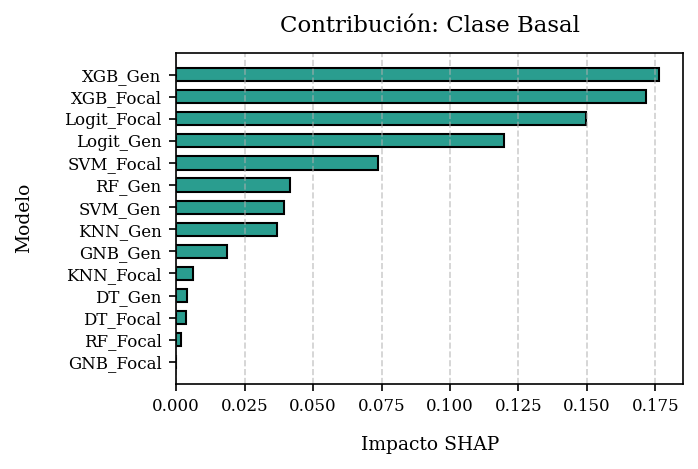

In [51]:
plot_shap_contribution(df_figura, "Basal")

Por el contrario, se observa una marcada redundancia operativa en modelos cuya contribución al diagnóstico basal resultó prácticamente insignificante. Técnicas como *Decision Trees* o *Gaussian Naive Bayes* mostraron impactos SHAP cercanos a cero, evidenciando que su aporte en la consolidación de la clase Basal es nulo dentro de la lógica del meta-modelo. Esta disparidad sugiere que la arquitectura de stacking ha aprendido a desestimar de forma autónoma las fuentes de información menos precisas, priorizando las configuraciones con mayor robustez analítica. Esta especialización jerárquica no solo valida la eficiencia del ensamble, sino que justifica la simplificación del pipeline al identificar clasificadores cuya participación en la definición del estado normal es marginal frente a la solidez de los modelos líderes.

A diferencia de la Clase Basal, donde el meta-modelo integra probabilidades de todo el espectro clínico para consolidar la normalidad, el arbitraje en la detección de eventos focales opera bajo una lógica de filtrado restrictivo. En esta configuración, el sistema limita el flujo de información a las probabilidades asociadas exclusivamente a la clase focal, alterando drásticamente la jerarquía de contribución. El análisis mediante valores SHAP revela que esta especialización facilita la integración de nuevos clasificadores expertos, como el *Random Forest*, cuyo impacto desplaza la confianza del ensamble hacia arquitecturas capaces de aislar las singularidades de la señal focal de manera independiente y sin la atenuación de modelos generalistas.


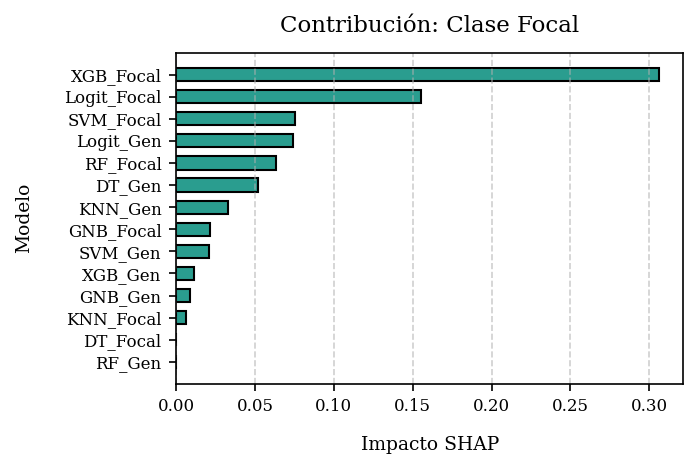

In [52]:
plot_shap_contribution(df_figura, "Focal")

Esta redistribución evidencia que la eficiencia del stacking no solo radica en la calidad de los clasificadores, sino en la restricción inteligente de la entrada. Mientras que en el estado basal la redundancia operativa es una herramienta de estabilidad, en el contexto focal esta se convierte en una fuente de distorsión; al restringir el acceso a la clase objetivo e incorporar expertos especializados, el meta-modelo ha transformado su lógica de arbitraje hacia un detector de alta precisión. Esta transición subraya la capacidad del sistema para reconocer qué modelos poseen la mayor competencia diagnóstica ante la sutilidad de los patrones focales, garantizando la robustez necesaria frente a la complejidad ictal.

Finalmente en lo que respecta a la detección de crisis generalizadas, el meta-modelo mantiene la lógica de filtrado restrictivo aplicada previamente, focalizando su arbitraje únicamente sobre las probabilidades de la clase objetivo. No obstante, el análisis de contribución mediante valores SHAP revela una mutación jerárquica significativa: el predominio de las arquitecturas de *Gradient Boosting* es desplazado por el *Random Forest*, que emerge como el predictor con mayor impacto diagnóstico. Este cambio de paradigma sugiere que, ante la morfología distintiva de las crisis generalizadas, el ensamble ha reconfigurado su estrategia de votación, otorgando prioridad a la capacidad de generalización y modelado no lineal de los bosques aleatorios sobre la optimización iterativa de XGBoost.


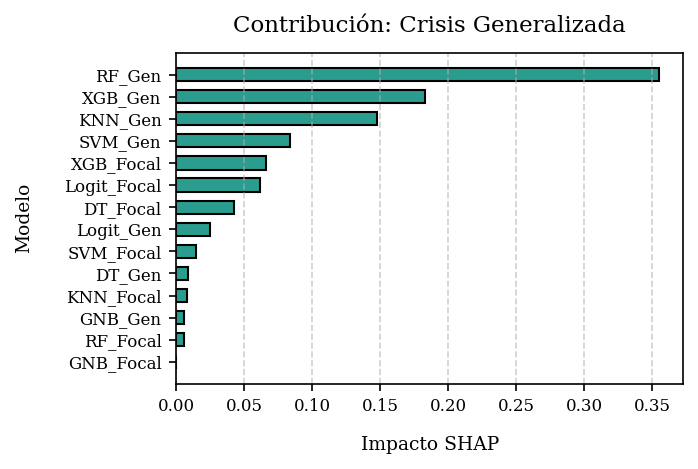

In [53]:
plot_shap_contribution(df_figura, "Gen")

Esta transición subraya la adaptabilidad del sistema, confirmando que la jerarquía de importancia es una respuesta directa a la naturaleza del evento ictal y no una propiedad fija del ensamble. Mientras que en las crisis focales el sistema se apoyaba en la precisión quirúrgica del Boosting, en el contexto de las crisis generalizadas el meta-modelo ha identificado en el *Random Forest* una competencia diagnóstica superior. Esta especialización ratifica que la eficiencia del pipeline reside en su capacidad para ajustar dinámicamente el peso de cada experto; el ensamble no solo clasifica el evento, sino que selecciona activamente la inteligencia técnica, ya sea *Boosting* o *Random Forest*, que mejor captura la firma electrofisiológica de la patología observada, garantizando así una detección altamente afinada al contexto clínico.

# Conclusión

El análisis de explicabilidad mediante valores SHAP confirma que la arquitectura de stacking ha trascendido la clasificación estática, consolidándose como un sistema de arbitraje clínico adaptativo que ajusta su lógica de decisión según el estado neurofisiológico detectado. La transición observada, desde la integración generalista en la Clase Basal hasta la especialización restringida en los eventos focales y generalizados, ratifica que la eficiencia del modelo no reside solo en su capacidad predictiva, sino en su habilidad para discernir y priorizar jerárquicamente a los clasificadores más competentes frente a la firma electrofisiológica de cada crisis.

En conclusión, este comportamiento valida contundentemente la justificación teórica del stacking, demostrando que la arquitectura ha aprendido a explotar las fortalezas individuales de los modelos base para minimizar la incertidumbre diagnóstica. Al delegar selectivamente el arbitraje a expertos como Random Forest o Gradient Boosting según la naturaleza de la señal, el sistema ha logrado una robustez operativa que garantiza precisión clínica frente a la variabilidad inter-sujeto, cumpliendo así con el propósito fundamental de integrar un flujo de trabajo analítico eficiente, transparente y especializado para el monitoreo epiléptico.